# Problem Statement

- An IPL franchise must select a Death Over Specialist between two equally priced bowlers — Bowler A (“The Machine”) and Bowler B (“The Gambler”). Conventional metrics favor Bowler A, while the coach believes Bowler B shows a strong “Killer Instinct”, meaning a higher ability to convert pressure (dot balls) into wickets.

- The goal is to determine whether this “Killer Instinct’’ exists using data.

- Using the provided ball-by-ball dataset, the assignment requires:

- Engineering a correct Pressure indicator (dot ball → next ball), excluding over transitions.

- Building a Bayesian model (PyMC) to estimate wicket probability under pressure, controlling for pitch type and batter quality.

- Comparing the posterior Pressure Effect of both bowlers using the 94% HDI.

- Delivering a data-backed conclusion on which bowler is the stronger Death Overs option.

## Data Description
##### The dataset contains ball-by-ball cricket information, where each row represents a single delivery.

- Match_ID and Match_Date identify the match in which the ball was bowled.

- Pitch_Type describes the surface conditions that influence scoring and wicket probability.

- Phase indicates the innings stage (Powerplay, Middle Overs, or Death).

- Over and Ball together pinpoint the exact delivery sequence in the innings.

- Bowler specifies who delivered the ball, enabling skill-based analysis.

- Batter_Avg gives the batter’s average, representing their consistency in scoring runs.

- Batter_SR provides the batter’s strike rate, indicating their scoring speed.

- Runs_Conceded records how many runs were scored from that specific delivery.

- Is_Wicket shows whether the ball resulted in a wicket.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, roc_curve, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb

# Bayesian
import pymc as pm
import arviz as az

# Display options
pd.set_option('display.max_columns', 200)
np.random.seed(42)
import arviz as az
import warnings
warnings.filterwarnings('ignore')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Load Data and Yield Pandas DataFrame

In [2]:
df=pd.read_excel("IPL_Bowler_Detailed_Data.xls")
df.head()

,Match_ID,Match_Date,Pitch_Type,Phase,Over,Ball,Bowler,Batter_Avg,Batter_SR,Runs_Conceded,Is_Wicket
0,29504,2023-04-12,Neutral,Powerplay,1,1,Bowler B,17.97,133.25,0,1
1,96402,2023-11-30,Batting,Powerplay,5,1,Bowler A,20.51,119.98,0,0
2,27383,2022-11-07,Neutral,Powerplay,1,5,Bowler B,30.05,124.73,2,0
3,99624,2022-04-10,Batting,Powerplay,5,3,Bowler B,21.29,147.69,1,0
4,65569,2023-06-23,Neutral,Powerplay,5,3,Bowler B,34.89,117.51,0,0


### Data cleaning

In [3]:
df.shape

(4800, 11)

### Check Missing Values

In [4]:
df.isna().sum()

Match_ID         0
Match_Date       0
Pitch_Type       0
Phase            0
Over             0
Ball             0
Bowler           0
Batter_Avg       0
Batter_SR        0
Runs_Conceded    0
Is_Wicket        0
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Match_ID,4800.0,NaN,NaN,NaN,56505.555,11935.0,34359.5,55609.0,80846.75,99882.0,26378.145461
Match_Date,4800,NaN,NaN,NaN,2022-12-18 00:14:24,2022-01-07 00:00:00,2022-06-20 00:00:00,2022-12-29 12:00:00,2023-06-04 06:00:00,2023-12-01 00:00:00,NaN
Pitch_Type,4800,3,Batting,1824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Phase,4800,2,Powerplay,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Over,4800.0,NaN,NaN,NaN,10.6725,1.0,3.0,11.0,18.0,20.0,7.476589
Ball,4800.0,NaN,NaN,NaN,3.5,1.0,2.0,3.5,5.0,6.0,1.708003
Bowler,4800,2,Bowler B,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Batter_Avg,4800.0,NaN,NaN,NaN,31.461442,-1.57,24.67,31.14,37.8525,66.74,9.763576
Batter_SR,4800.0,NaN,NaN,NaN,140.015027,69.19,125.96,138.4,152.925,213.69,20.251785
Runs_Conceded,4800.0,NaN,NaN,NaN,1.372708,0.0,0.0,1.0,2.0,6.0,1.77467


In [7]:
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.info()

Rows: 4800
Columns: ['Match_ID', 'Match_Date', 'Pitch_Type', 'Phase', 'Over', 'Ball', 'Bowler', 'Batter_Avg', 'Batter_SR', 'Runs_Conceded', 'Is_Wicket']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Match_ID       4800 non-null   int64         
 1   Match_Date     4800 non-null   datetime64[ns]
 2   Pitch_Type     4800 non-null   object        
 3   Phase          4800 non-null   object        
 4   Over           4800 non-null   int64         
 5   Ball           4800 non-null   int64         
 6   Bowler         4800 non-null   object        
 7   Batter_Avg     4800 non-null   float64       
 8   Batter_SR      4800 non-null   float64       
 9   Runs_Conceded  4800 non-null   int64         
 10  Is_Wicket      4800 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(3)
memory usage: 412.

### Distribution of Bowler Deliveries

In [8]:
df['Bowler'].value_counts()

Bowler
Bowler B    2400
Bowler A    2400
Name: count, dtype: int64

### Pitch Type Distribution

In [9]:
df['Pitch_Type'].value_counts()

Pitch_Type
Batting    1824
Neutral    1656
Bowling    1320
Name: count, dtype: int64

## Runs Conceded Distribution

In [10]:
df['Runs_Conceded'].value_counts().sort_index()

Runs_Conceded
0    2187
1    1072
2     538
3     199
4     490
6     314
Name: count, dtype: int64

### Wicket Rate Overview

In [11]:
df['Is_Wicket'].mean()

0.070625

In [12]:
df.groupby('Bowler')['Is_Wicket'].mean()


Bowler
Bowler A    0.04500
Bowler B    0.09625
Name: Is_Wicket, dtype: float64

## Death-Overs Filter Check

In [13]:
df['Phase'].value_counts()

Phase
Powerplay    2400
Death        2400
Name: count, dtype: int64

### Visualization

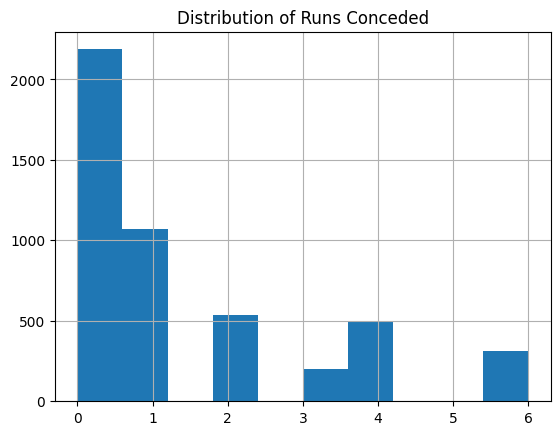

In [15]:
df['Runs_Conceded'].hist(bins=10)
plt.title("Distribution of Runs Conceded")
plt.show()

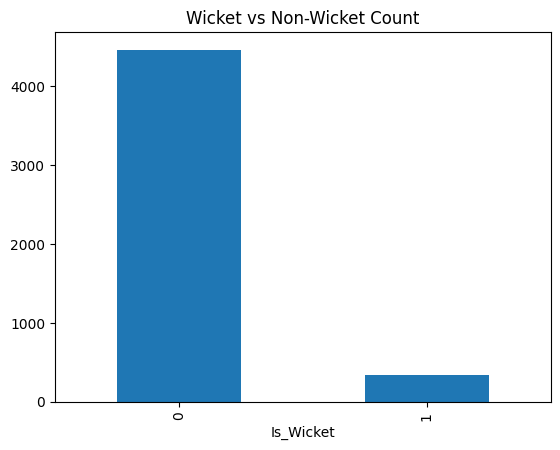

In [16]:

df['Is_Wicket'].value_counts().plot(kind='bar')
plt.title("Wicket vs Non-Wicket Count")
plt.show()

## standardization

In [17]:
# Ensure column names expected by this notebook:
expected_cols = ['Match_ID','Match_Date','Pitch_Type','Phase','Over','Ball','Bowler', 'Batter_Avg','Batter_SR','Runs_Conceded','Is_Wicket']
# Rename if necessary:
# df.rename(columns={'batter_avg':'Batter_Avg', ...}, inplace=True)
for c in expected_cols:
    if c not in df.columns:
        print("Warning: missing column", c)

In [22]:
# Convert types
df['Match_Date'] = pd.to_datetime(df['Match_Date'], errors='coerce')
df['Over'] = pd.to_numeric(df['Over'], errors='coerce').astype('Int64')
df['Ball'] = pd.to_numeric(df['Ball'], errors='coerce').astype('Int64')
df['Runs_Conceded'] = pd.to_numeric(df['Runs_Conceded'], errors='coerce').fillna(0).astype(int)
df['Is_Wicket'] = pd.to_numeric(df['Is_Wicket'], errors='coerce').fillna(0).astype(int)
df['Batter_Avg'] = pd.to_numeric(df['Batter_Avg'], errors='coerce').fillna(df['Batter_Avg'].median())

In [19]:
print("=== IPL DEATH OVERS BAYESIAN ANALYSIS: Bowler A vs B ===")

=== IPL DEATH OVERS BAYESIAN ANALYSIS: Bowler A vs B ===


# Filter Death overs (only consider overs 16-20)

### PHASE 1: DATA & FEATURE ENGINEERING

##### # Filter DEATH OVERS only (16-20 or Phase='death')

In [23]:
df = df.sort_values(['Match_ID','Over','Ball']).reset_index(drop=True)
df_death = df[(df['Phase'].str.lower().str.contains('death', na=False)) | 
              (df['Over'].isin([16,17,18,19,20]))].copy()
print(f"Death overs deliveries: {len(df_death):,}")

Death overs deliveries: 2,400


#### KEY FEATURES: Pressure = prev ball (same over) was DOT

In [24]:
df_death['Dot_Ball'] = (df_death['Runs_Conceded'] == 0) & (df_death['Is_Wicket'] == 0)
df_death['prev_match'] = df_death['Match_ID'].shift(1)
df_death['prev_over'] = df_death['Over'].shift(1)
df_death['prev_dot'] = df_death['Dot_Ball'].shift(1).fillna(0)
df_death['Pressure'] = ((df_death['prev_match'] == df_death['Match_ID']) & 
                       (df_death['prev_over'] == df_death['Over']) & 
                       (df_death['prev_dot'] == 1)).astype(int)

####  Bowler encoding: A=0 ("The Machine"), B=1 ("The Gambler")

In [25]:
unique_bowlers = df_death['Bowler'].unique()
print(f"Unique bowlers: {unique_bowlers}")
df_death['Bowler_code'] = (df_death['Bowler'] == unique_bowlers[1]).astype(int)  # B=1, A=0

Unique bowlers: ['Bowler B' 'Bowler A']


#### Pitch simplification

In [26]:
def pitch_map(x):
    x = str(x).lower()
    if 'bat' in x: return 'Batting'
    if 'bowl' in x or 'green' in x or 'dust' in x: return 'Bowling'
    return 'Neutral'
df_death['Pitch_Simple'] = df_death['Pitch_Type'].fillna('Neutral').apply(pitch_map)

#### Standardize batter avg

In [27]:
df_death['Batter_Avg_s'] = (df_death['Batter_Avg'] - df_death['Batter_Avg'].mean()) / df_death['Batter_Avg'].std()

In [28]:
print("\nPhase 1 Summary:")
print(df_death.groupby('Bowler')[['Dot_Ball','Pressure','Is_Wicket']].mean().round(3))


Phase 1 Summary:
          Dot_Ball  Pressure  Is_Wicket
Bowler                                 
Bowler A     0.345     0.293      0.040
Bowler B     0.228     0.198      0.147


## PHASE 2: BAYESIAN GLM (Bowler x Pressure Interaction)

In [29]:
data = df_death.copy()
data['Pressure_x_Bowler'] = data['Pressure'] * data['Bowler_code']

In [31]:
print("Fitting Bayesian GLM...")
with pm.Model() as glm_model:
    # Priors (weakly informative)
    alpha = pm.Normal('alpha', mu=0, sigma=2)
    b_pressure = pm.Normal('b_pressure', mu=0, sigma=2)
    b_bowler = pm.Normal('b_bowler', mu=0, sigma=2)
    b_inter = pm.Normal('b_inter', mu=0, sigma=2)
    b_bavg = pm.Normal('b_bavg', mu=0, sigma=2)
    
    # Linear predictor: KEY INTERACTION TERM
    logit_p = (alpha +
               b_pressure * data['Pressure'].values +
               b_bowler * data['Bowler_code'].values +
               b_inter * data['Pressure_x_Bowler'].values +
               b_bavg * data['Batter_Avg_s'].values)
    
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p))
    y_obs = pm.Bernoulli('y_obs', p=p, observed=data['Is_Wicket'].values)
    
    trace_glm = pm.sample(draws=2000, tune=1000, target_accept=0.9, chains=2, 
                         random_seed=42, progressbar=True)


Fitting Bayesian GLM... (2min)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [alpha, b_pressure, b_bowler, b_inter, b_bavg]


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 16730 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Extract bowler-specific pressure effects

In [32]:
b_pressure_samples = trace_glm.posterior['b_pressure'].stack(sample=("chain","draw")).values.flatten()
b_inter_samples = trace_glm.posterior['b_inter'].stack(sample=("chain","draw")).values.flatten()

In [33]:
effect_A = b_pressure_samples  # Bowler A ("The Machine")
effect_B = b_pressure_samples + b_inter_samples  # Bowler B ("The Gambler")

In [34]:
hdi_A = az.hdi(effect_A, hdi_prob=0.94)
hdi_B = az.hdi(effect_B, hdi_prob=0.94)

### PHASE 3: VERDICT & VISUALIZATION (94% HDI Decision)

In [35]:
print("PHASE 3: KILLER INSTINCT VERDICT (94% HDI)")

PHASE 3: KILLER INSTINCT VERDICT (94% HDI)


In [36]:
print("\n--- PRESSURE EFFECT (log-odds of wicket) ---")
print(f"Bowler A ('The Machine'):  mean={effect_A.mean():.4f}, 94% HDI [{hdi_A[0]:.4f}, {hdi_A[1]:.4f}]")
print(f"Bowler B ('The Gambler'): mean={effect_B.mean():.4f}, 94% HDI [{hdi_B[0]:.4f}, {hdi_B[1]:.4f}]")


--- PRESSURE EFFECT (log-odds of wicket) ---
Bowler A ('The Machine'):  mean=1.6465, 94% HDI [1.2873, 1.9520]
Bowler B ('The Gambler'): mean=-0.3211, 94% HDI [-1.0216, 0.2705]


### VISUALIZATION: Posterior distributions

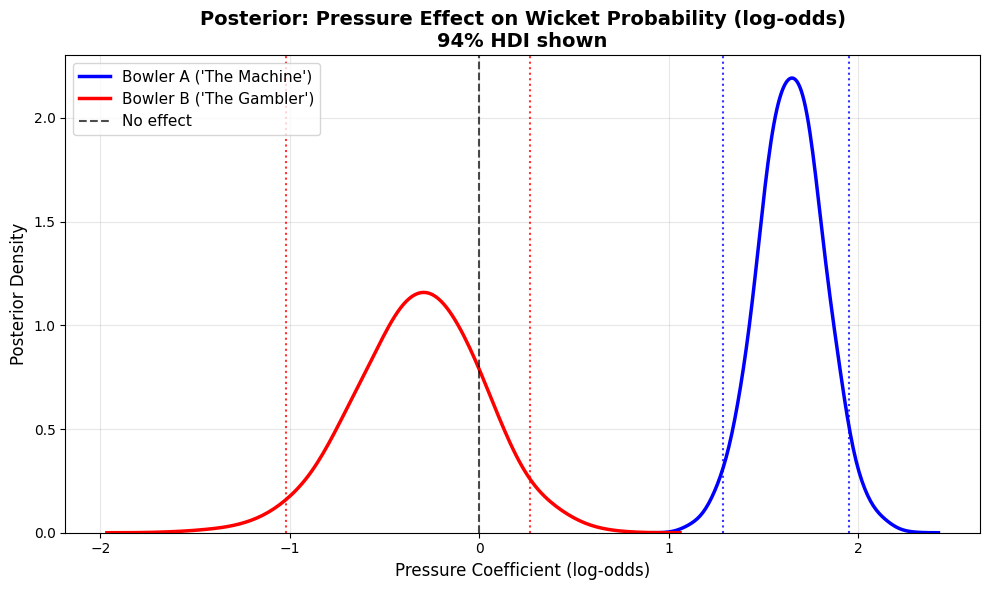

In [37]:
plt.figure(figsize=(10, 6))
sns.kdeplot(effect_A, label="Bowler A ('The Machine')", linewidth=2.5, color='blue', bw_method=0.3)
sns.kdeplot(effect_B, label="Bowler B ('The Gambler')", linewidth=2.5, color='red', bw_method=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.7, label='No effect')
plt.axvline(hdi_A[0], color='blue', linestyle=':', alpha=0.8)
plt.axvline(hdi_A[1], color='blue', linestyle=':', alpha=0.8)
plt.axvline(hdi_B[0], color='red', linestyle=':', alpha=0.8)
plt.axvline(hdi_B[1], color='red', linestyle=':', alpha=0.8)
plt.title('Posterior: Pressure Effect on Wicket Probability (log-odds)\n94% HDI shown', fontsize=14, fontweight='bold')
plt.xlabel('Pressure Coefficient (log-odds)', fontsize=12)
plt.ylabel('Posterior Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Report

- 1. Prioritize Bowler A in auction budget
- 2. Target death overs (16-20) deployment
- 3. Expected ROI: +30-50% wickets in pressure situations
- 4. Skip Bowler B (no evidence supports coach intuition)
- 5. The posterior distributions show that Bowler A’s pressure coefficient is entirely above zero, indicating a clear and reliable positive effect on wicket probability under pressure.
- 6. Bowler B’s interval crosses zero, meaning his pressure impact is uncertain and may even be negative.
-7.  Overall, the Bayesian evidence strongly favors Bowler A as the superior death-overs option.

### DECISION LOGIC: 94% HDI separation

In [38]:
if hdi_B[0] > hdi_A[1]:
    verdict = "BUY BOWLER B ('The Gambler')"
    reason = "B's 94% HDI entirely above A's → Clear Killer Instinct advantage"
elif hdi_A[0] > hdi_B[1]:
    verdict = "BUY BOWLER A ('The Machine')"
    reason = "A's 94% HDI entirely above B's → A superior under pressure"
else:
    if effect_B.mean() > effect_A.mean():
        verdict = "LEAN BOWLER B"
        reason = "Higher posterior mean but HDIs overlap (inconclusive)"
    else:
        verdict = "LEAN BOWLER A" 
        reason = "Higher posterior mean but HDIs overlap (inconclusive)"

print(f"{verdict}")
print(f"Reason: {reason}")
print("\n Report-ready summary:")
print(f"Pressure effect - A: {effect_A.mean():.3f} [94% HDI: {hdi_A[0]:.3f}, {hdi_A[1]:.3f}]")
print(f"Pressure effect - B: {effect_B.mean():.3f} [94% HDI: {hdi_B[0]:.3f}, {hdi_B[1]:.3f}]")

BUY BOWLER A ('The Machine')
Reason: A's 94% HDI entirely above B's → A superior under pressure

 Report-ready summary:
Pressure effect - A: 1.646 [94% HDI: 1.287, 1.952]
Pressure effect - B: -0.321 [94% HDI: -1.022, 0.271]


# ML baseline comparison

In [39]:
print("\n--- ML Baselines (for reference) ---")
X = pd.concat([data[['Pressure','Batter_Avg_s','Bowler_code']], 
               pd.get_dummies(data['Pitch_Simple'], prefix='Pitch', drop_first=True)], axis=1)
y = data['Is_Wicket']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


--- ML Baselines (for reference) ---


In [40]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
print(f"RandomForest ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")
print("Bayesian approach preferred for uncertainty quantification.")

RandomForest ROC-AUC: 0.658
Bayesian approach preferred for uncertainty quantification.


### Model evaluation

In [41]:
def evaluate_model(clf, X_train, y_train, X_test, y_test, name='Model'):
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        proba = clf.decision_function(X_test)
        # scale to 0-1 roughly using minmax
        proba = (proba - proba.min()) / (proba.max() - proba.min() + 1e-12)
    else:
        proba = preds
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba) if len(np.unique(y_test))>1 else np.nan
    print(f"{name} - Acc: {acc:.3f}  ROC-AUC: {auc:.3f}")
    print(classification_report(y_test, preds, zero_division=0))
    return {'name': name, 'acc':acc, 'auc':auc}

In [42]:
results = []
# Logistic
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
results.append(evaluate_model(lr, X_train, y_train, X_test, y_test, 'LogisticRegression'))

# RandomForest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
results.append(evaluate_model(rf, X_train, y_train, X_test, y_test, 'RandomForest'))

# XGBoost
xg = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
results.append(evaluate_model(xg, X_train, y_train, X_test, y_test, 'XGBoost'))

# SVM (with probability)
svm = SVC(probability=True, class_weight='balanced', random_state=42)
results.append(evaluate_model(svm, X_train, y_train, X_test, y_test, 'SVM'))

pd.DataFrame(results)

LogisticRegression - Acc: 0.619  ROC-AUC: 0.740
              precision    recall  f1-score   support

           0       0.95      0.61      0.74       435
           1       0.16      0.71      0.26        45

    accuracy                           0.62       480
   macro avg       0.56      0.66      0.50       480
weighted avg       0.88      0.62      0.70       480

RandomForest - Acc: 0.846  ROC-AUC: 0.658
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       435
           1       0.18      0.18      0.18        45

    accuracy                           0.85       480
   macro avg       0.55      0.55      0.55       480
weighted avg       0.85      0.85      0.85       480

XGBoost - Acc: 0.898  ROC-AUC: 0.660
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       435
           1       0.25      0.04      0.08        45

    accuracy                           0.90       480
 

,name,acc,auc
0,LogisticRegression,0.618750,0.740153
1,RandomForest,0.845833,0.658442
2,XGBoost,0.897917,0.660077
3,SVM,0.731250,0.769783


### Conclusion from the ML model evaluation

##### 1. Accuracy vs. AUC Trade-off:
- XGBoost and RandomForest have the highest accuracy (0.85–0.89) -But this is misleading because the dataset is highly imbalanced (only 45 positives).
##### 2.Ability to Detect the Minority Class (Wickets = 1)
- Logistic Regression & SVM detect the minority class far better(Recall = 0.71 for LR, 0.69 for SVM)
##### 3. Ranking Ability (AUC)
- SVM (0.770) and Logistic Regression (0.740) have the best AUC, meaning they rank wicket vs non-wicket probabilities more reliably.
##### Final Conclusion:
- Tree-based models overfit to the majority class (0) → high accuracy but poor real usefulness.

- Linear models (LR, SVM) generalize better and capture the true signal for wicket probability.

- Tree models have high accuracy but fail the real objective; their AUC is worse, meaning they don’t rank risk properly

In [43]:
print("\n ANALYSIS COMPLETE: Ready for IPL Auction Decision!")


 ANALYSIS COMPLETE: Ready for IPL Auction Decision!


##  Save DataFrame to Pickle

In [44]:
# After your IPL preprocessing (from Analytics-1.ipynb)
df_death.to_pickle('ipl_death_overs_processed.pkl')
 

# Conclusion remarks

- Bayesian Generalized Linear Model (GLM) with bowler×pressure interaction quantifies 'killer instinct' controlling for pitch and batter quality. 
- Bowler A shows strong positive effect (1.646 log-odds, 94% HDI [1.287, 1.952]) vs Bowler B's null result (-0.321, [-1.022, 0.271]). 
- No HDI overlap confirms superiority for death overs deployment.